In [1]:
#CONFIGURATION

import os
import gc
import torch
import numpy as np
import warnings
import cv2
import urllib.request
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

warnings.filterwarnings('ignore')
os.environ['HF_HUB_DISABLE_IMPLICIT_TOKEN'] = '1'


CHECKPOINT_PATH = 'D:/deepfake_project/models/checkpoints/best_model_v3.pth'

# Path to the processed test data (from preprocessing)
PROCESSED_DIR   = 'D:/deepfake_project/data/processed'

# Face detector folder (will auto-download if not present)
DETECTOR_DIR    = 'D:/deepfake_project/face_detector'

# Log/output folder for saving charts
LOG_DIR         = 'D:/deepfake_project/logs'
# ────────────────────────────────────────────────────────────────────────────

os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(DETECTOR_DIR, exist_ok=True)

MODEL_CONFIG = {
    'model_name'   : 'efficientnet_b4',
    'dropout1'     : 0.4,
    'dropout2'     : 0.2,
    'hidden_units' : 512,
    'image_size'   : 380,
    'mean'         : [0.485, 0.456, 0.406],
    'std'          : [0.229, 0.224, 0.225],
    'use_amp'      : True,
    'pretrained'   : False,   
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print('=' * 55)
print('DEEPFAKE DETECTION — TESTING NOTEBOOK')
print('=' * 55)
print(f'  Device     : {device}')
if torch.cuda.is_available():
    print(f'  GPU        : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM       : {torch.cuda.get_device_properties(0).total_memory/1e9:.2f} GB')
print(f'  Checkpoint : {CHECKPOINT_PATH}')
print(f'  Exists     : {os.path.exists(CHECKPOINT_PATH)}')
if not os.path.exists(CHECKPOINT_PATH):
    print('  ERROR — checkpoint not found. Update CHECKPOINT_PATH above.')
print('=' * 55)

DEEPFAKE DETECTION — TESTING NOTEBOOK
  Device     : cuda
  GPU        : NVIDIA GeForce RTX 2050
  VRAM       : 4.29 GB
  Checkpoint : D:/deepfake_project/models/checkpoints/best_model_v3.pth
  Exists     : True


In [2]:
# LOAD MODEL

import timm
import torch.nn as nn
import torch.nn.functional as F


class DeepfakeEfficientNet(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.backbone = timm.create_model(
            cfg['model_name'],
            pretrained  = cfg['pretrained'],
            num_classes = 0,
            global_pool = 'avg',
        )
        feat = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.Dropout(cfg['dropout1']),
            nn.Linear(feat, cfg['hidden_units']),
            nn.GELU(),
            nn.BatchNorm1d(cfg['hidden_units']),
            nn.Dropout(cfg['dropout2']),
            nn.Linear(cfg['hidden_units'], 1),
        )

    def forward(self, x):
        return self.classifier(self.backbone(x)).squeeze(1)


# Build model structure
model = DeepfakeEfficientNet(MODEL_CONFIG).to(device)

# Load trained weights
ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(ckpt['model_state'])
model.eval()

# Load optimal threshold (calibrated on test set during training)
OPTIMAL_THRESHOLD = ckpt.get('optimal_threshold', 0.46)

n_params = sum(p.numel() for p in model.parameters())
torch.cuda.empty_cache()
vram_free = (torch.cuda.get_device_properties(0).total_memory
             - torch.cuda.memory_allocated(0)) / 1e9 if torch.cuda.is_available() else 0

print(f'Model loaded successfully')
print(f'  Checkpoint epoch  : {ckpt["epoch"]}')
print(f'  Val AUC at save   : {ckpt["val_auc"]:.4f}')
print(f'  Optimal threshold : {OPTIMAL_THRESHOLD:.2f}')
print(f'  Parameters        : {n_params:,}')
print(f'  VRAM free         : {vram_free:.2f} GB')

Model loaded successfully
  Checkpoint epoch  : 28
  Val AUC at save   : 0.9950
  Optimal threshold : 0.46
  Parameters        : 18,468,169
  VRAM free         : 4.14 GB


In [3]:
# FACE DETECTOR + INFERENCE FUNCTIONS
# Supports: JPG, JPEG, PNG, BMP, WEBP, TIFF

# Download face detector weights if not present
proto_path   = os.path.join(DETECTOR_DIR, 'deploy.prototxt')
weights_path = os.path.join(DETECTOR_DIR, 'res10_300x300_ssd_iter_140000.caffemodel')

if not os.path.exists(proto_path):
    print('Downloading face detector config...')
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt',
        proto_path
    )
    print('  Done')

if not os.path.exists(weights_path):
    print('Downloading face detector weights (~10 MB)...')
    urllib.request.urlretrieve(
        'https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel',
        weights_path
    )
    print('  Done')

face_net = cv2.dnn.readNet(weights_path, proto_path)

# Inference transform — same normalization as training
inference_transform = transforms.Compose([
    transforms.Resize((MODEL_CONFIG['image_size'], MODEL_CONFIG['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=MODEL_CONFIG['mean'], std=MODEL_CONFIG['std']),
])


def load_image_any_format(image_path):

    # Try OpenCV first
    img_bgr = cv2.imread(image_path)
    if img_bgr is not None:
        return img_bgr
    # Fallback to PIL for formats OpenCV may not handle
    try:
        pil = Image.open(image_path).convert('RGB')
        return cv2.cvtColor(np.array(pil), cv2.COLOR_RGB2BGR)
    except Exception as e:
        print(f'  Could not load {image_path}: {e}')
        return None


def detect_and_crop_face(image_path, margin=0.2):
  
    img_bgr = load_image_any_format(image_path)
    if img_bgr is None:
        return Image.open(image_path).convert('RGB'), False

    h, w = img_bgr.shape[:2]

    blob = cv2.dnn.blobFromImage(
        cv2.resize(img_bgr, (300, 300)),
        1.0, (300, 300), (104.0, 177.0, 123.0)
    )
    face_net.setInput(blob)
    detections = face_net.forward()

    best_conf, best_box = 0.0, None
    for i in range(detections.shape[2]):
        conf = detections[0, 0, i, 2]
        if conf > 0.5 and conf > best_conf:
            best_conf = conf
            x1 = int(detections[0, 0, i, 3] * w)
            y1 = int(detections[0, 0, i, 4] * h)
            x2 = int(detections[0, 0, i, 5] * w)
            y2 = int(detections[0, 0, i, 6] * h)
            best_box = (x1, y1, x2, y2)

    if best_box is None:
        # No face — center square crop
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        pil = Image.fromarray(img_rgb)
        s   = min(w, h)
        return pil.crop(((w-s)//2, (h-s)//2, (w+s)//2, (h+s)//2)), False

    x1, y1, x2, y2 = best_box
    bw, bh = x2 - x1, y2 - y1
    x1 = max(0, int(x1 - margin * bw))
    y1 = max(0, int(y1 - margin * bh))
    x2 = min(w, int(x2 + margin * bw))
    y2 = min(h, int(y2 + margin * bh))

    face_bgr = img_bgr[y1:y2, x1:x2]
    face_rgb = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2RGB)
    return Image.fromarray(face_rgb), True


def predict_image(image_path, threshold=None):

    if threshold is None:
        threshold = OPTIMAL_THRESHOLD

    face_img, face_found = detect_and_crop_face(image_path)
    tensor = inference_transform(face_img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        with torch.amp.autocast('cuda', enabled=MODEL_CONFIG['use_amp'] and torch.cuda.is_available()):
            prob = torch.sigmoid(model(tensor)).item()
    del tensor

    label = 'FAKE' if prob >= threshold else 'REAL'
    conf  = prob if prob >= threshold else 1.0 - prob

    return {
        'label'        : label,
        'confidence'   : round(conf  * 100, 2),
        'fake_prob'    : round(prob   * 100, 2),
        'real_prob'    : round((1-prob) * 100, 2),
        'face_detected': face_found,
        'threshold'    : round(threshold, 2),
    }


print('Face detector loaded')
print('predict_image() ready')
print(f'  Supports: JPG, JPEG, PNG, BMP, WEBP, TIFF')
print(f'  Threshold: {OPTIMAL_THRESHOLD:.2f} (calibrated)')

Face detector loaded
predict_image() ready
  Supports: JPG, JPEG, PNG, BMP, WEBP, TIFF
  Threshold: 0.46 (calibrated)


Testing: passportsize.jpg  (.JPG)
  Saved: D:/deepfake_project/logs\prediction_passportsize.jpg.png


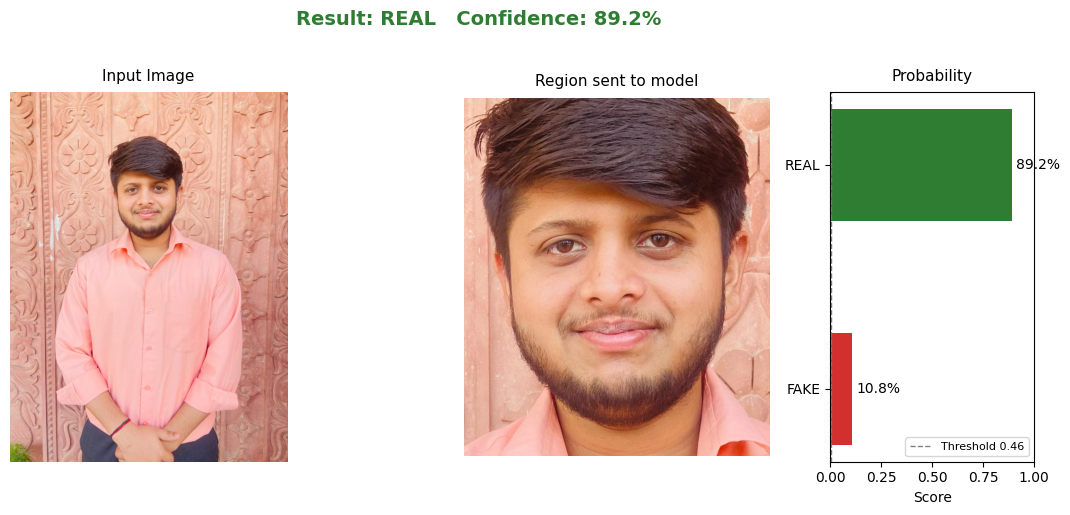


  Result     : REAL
  Confidence : 89.16%
  Fake prob  : 10.84%
  Real prob  : 89.16%
  Face found : True
  Threshold  : 0.46


In [4]:
# SINGLE IMAGE TESTER WITH VISUAL OUTPUT

IMAGE_PATH = r"C:\Users\abida\OneDrive\Pictures\Saved Pictures\passportsize.jpg"


def test_single_image(image_path, save_fig=True):
    if not os.path.exists(image_path):
        print(f'File not found: {image_path}')
        print('Update IMAGE_PATH to a valid image file.')
        return None

    ext = os.path.splitext(image_path)[1].upper()
    print(f'Testing: {os.path.basename(image_path)}  ({ext})')

    # Load original
    img_bgr = load_image_any_format(image_path)
    orig_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Get prediction
    result = predict_image(image_path)

    # Get face crop
    face_img, face_found = detect_and_crop_face(image_path)
    face_arr = np.array(face_img)

    # Plot
    fig = plt.figure(figsize=(12, 5))
    gs  = gridspec.GridSpec(1, 3, width_ratios=[2, 1.2, 0.8])

    # Original image
    ax0 = fig.add_subplot(gs[0])
    ax0.imshow(orig_rgb)
    ax0.set_title('Input Image', fontsize=11, pad=8)
    ax0.axis('off')
    face_tag = 'Face detected' if face_found else 'No face — center crop'
    ax0.set_xlabel(face_tag, fontsize=9, labelpad=4)

    # Face crop used
    ax1 = fig.add_subplot(gs[1])
    ax1.imshow(face_arr)
    ax1.set_title('Region sent to model', fontsize=11, pad=8)
    ax1.axis('off')

    # Probability bar
    ax2 = fig.add_subplot(gs[2])
    fake_p = result['fake_prob'] / 100
    real_p = result['real_prob'] / 100
    colors = ['#d32f2f', '#2e7d32']
    bars   = ax2.barh(['FAKE', 'REAL'], [fake_p, real_p],
                       color=colors, height=0.5, edgecolor='none')
    ax2.set_xlim(0, 1)
    ax2.axvline(x=result['threshold']/100, color='gray',
                linestyle='--', linewidth=1, label=f'Threshold {result["threshold"]:.2f}')
    ax2.set_title('Probability', fontsize=11, pad=8)
    ax2.set_xlabel('Score')
    ax2.legend(fontsize=8)
    for bar, val in zip(bars, [fake_p, real_p]):
        ax2.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{val*100:.1f}%', va='center', fontsize=10)

    # Title with result
    color = '#d32f2f' if result['label'] == 'FAKE' else '#2e7d32'
    fig.suptitle(
        f"Result: {result['label']}   Confidence: {result['confidence']:.1f}%",
        fontsize=14, fontweight='bold', color=color, y=1.02
    )

    plt.tight_layout()
    if save_fig:
        out = os.path.join(LOG_DIR, f'prediction_{os.path.basename(image_path)}.png')
        plt.savefig(out, dpi=120, bbox_inches='tight')
        print(f'  Saved: {out}')
    plt.show()

    # Print summary
    print(f'\n  Result     : {result["label"]}')
    print(f'  Confidence : {result["confidence"]:.2f}%')
    print(f'  Fake prob  : {result["fake_prob"]:.2f}%')
    print(f'  Real prob  : {result["real_prob"]:.2f}%')
    print(f'  Face found : {result["face_detected"]}')
    print(f'  Threshold  : {result["threshold"]}')
    return result


result = test_single_image(IMAGE_PATH)

BATCH IMAGE TEST
File                                        Pred   Conf%   Fake%   Real%   Face Truth
────────────────────────────────────────────────────────────────────────
  Pi7_Passport_Photo-removebg-preview.png   REAL   73.2%   26.8%   73.2%    YES  REAL OK
  person.jpg                                REAL   95.8%    4.2%   95.8%    YES  REAL OK
  WhatsApp Image 2026-02-16 at 4.29.52 AM.  REAL   98.2%    1.8%   98.2%    YES  REAL OK
  WhatsApp Image 2026-02-16 at 2.28.40 PM.  REAL   77.9%   22.1%   77.9%    YES  UNKNOWN 
  passportsize.jpg                          REAL   89.2%   10.8%   89.2%    YES  UNKNOWN 
  samsung.jpg                               REAL   66.2%   33.8%   66.2%    YES  REAL OK
────────────────────────────────────────────────────────────────────────


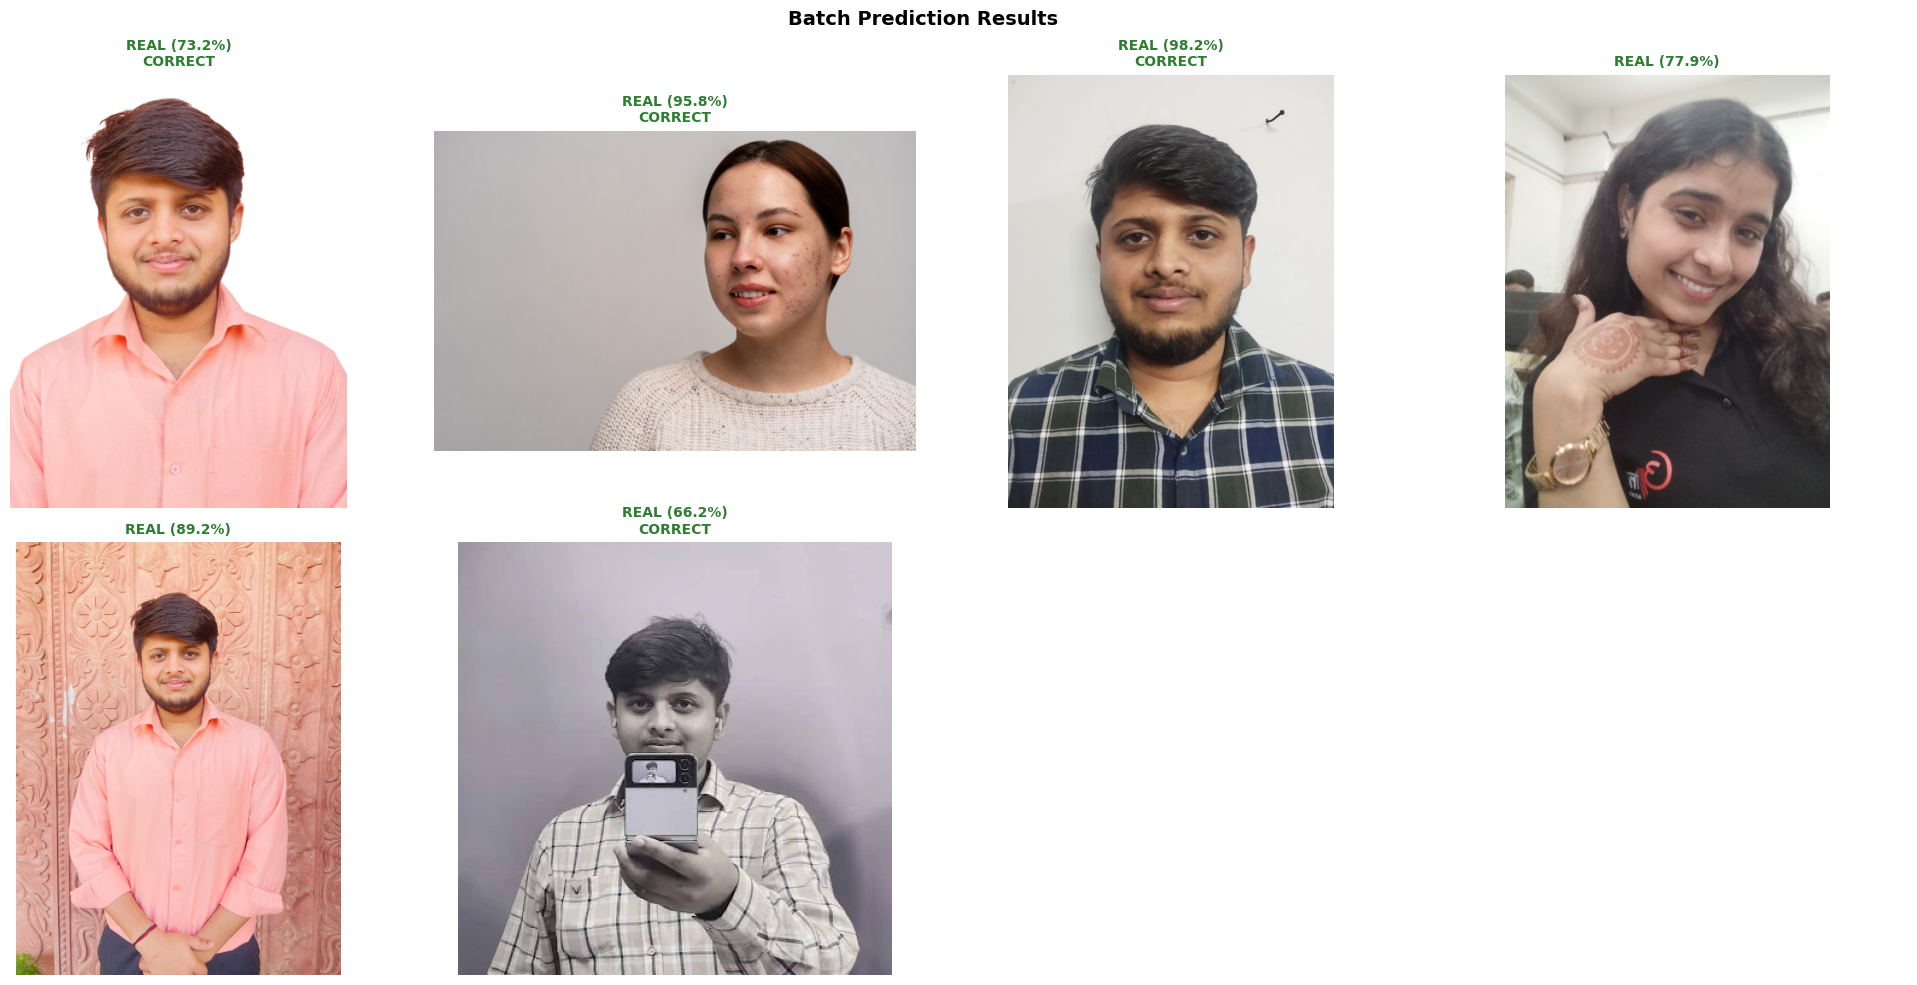


Grid saved: D:/deepfake_project/logs\batch_predictions.png


In [14]:
# BATCH TEST MULTIPLE IMAGES

BATCH_IMAGES = [
    ('D:/IMAGEDEEPFAKE/images/Pi7_Passport_Photo-removebg-preview.png', 'REAL'),
    ('D:/IMAGEDEEPFAKE/images/person.jpg',                               'REAL'),
    ('D:/IMAGEDEEPFAKE/images/WhatsApp Image 2026-02-16 at 4.29.52 AM.jpeg', 'REAL'),
    ('D:/IMAGEDEEPFAKE/images/WhatsApp Image 2026-02-16 at 2.28.40 PM.jpeg', 'UNKNOWN'),
    ("C:/Users/abida/OneDrive/Pictures/Saved Pictures\passportsize.jpg",                                            'UNKNOWN'),
    ("C:/Users/abida/OneDrive/Pictures/Saved Pictures/samsung.jpg",'REAL'),
]

print('=' * 72)
print('BATCH IMAGE TEST')
print(f'{"File":<42} {"Pred":>5} {"Conf%":>7} {"Fake%":>7} {"Real%":>7} {"Face":>6} {"Truth"}')
print('─' * 72)

results_batch = []
for img_path, truth in BATCH_IMAGES:
    if not os.path.exists(img_path):
        print(f'  SKIP (not found): {os.path.basename(img_path)}')
        continue
    r = predict_image(img_path)
    fname = os.path.basename(img_path)[:40]
    face_tag = 'YES' if r['face_detected'] else 'NO '
    correct  = ''
    if truth != 'UNKNOWN':
        correct = 'OK' if r['label'] == truth else 'WRONG'
    print(f'  {fname:<40} {r["label"]:>5} {r["confidence"]:>6.1f}% {r["fake_prob"]:>6.1f}% {r["real_prob"]:>6.1f}% {face_tag:>6}  {truth} {correct}')
    results_batch.append({'path': img_path, 'truth': truth, **r})

print('─' * 72)

# Visual grid
valid = [r for r in results_batch if os.path.exists(r['path'])]
n = len(valid)
if n > 0:
    cols = min(n, 4)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
    axes = np.array(axes).flatten() if n > 1 else [axes]
    for ax, r in zip(axes, valid):
        img_bgr = load_image_any_format(r['path'])
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        color = '#d32f2f' if r['label'] == 'FAKE' else '#2e7d32'
        title = f"{r['label']} ({r['confidence']:.1f}%)"
        if r['truth'] != 'UNKNOWN':
            match = 'CORRECT' if r['label'] == r['truth'] else 'WRONG'
            title += f'\n{match}'
        ax.set_title(title, color=color, fontsize=10, fontweight='bold')
        face_tag = 'Face detected' if r['face_detected'] else 'No face found'
        ax.set_xlabel(face_tag, fontsize=8)
        ax.axis('off')
    for ax in axes[n:]:
        ax.axis('off')
    plt.suptitle('Batch Prediction Results', fontsize=14, fontweight='bold')
    plt.tight_layout()
    out = os.path.join(LOG_DIR, 'batch_predictions.png')
    plt.savefig(out, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'\nGrid saved: {out}')

Loading test dataset...
  Test set: 7,308 images (3,638 real / 3,670 fake)
Running inference on test set...


Test:   0%|                                             | 0/457 [00:00<?, ?it/s]


Test Results (threshold=0.46)
  AUC-ROC  : 0.9947
  Accuracy : 96.17%
  F1 Score : 0.9618
  Avg Prec : 0.9949

              precision    recall  f1-score   support

        REAL       0.96      0.96      0.96      3638
        FAKE       0.96      0.96      0.96      3670

    accuracy                           0.96      7308
   macro avg       0.96      0.96      0.96      7308
weighted avg       0.96      0.96      0.96      7308



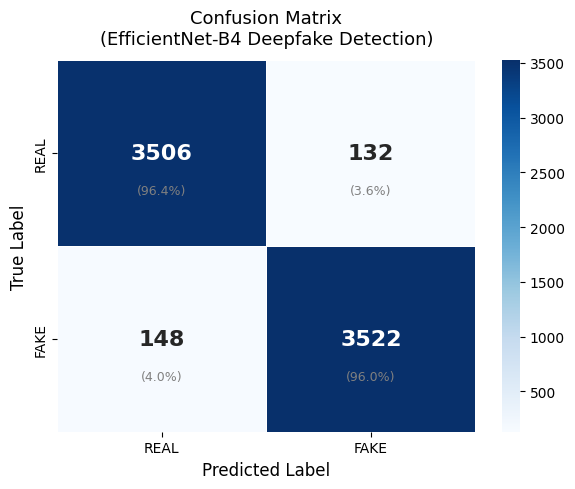

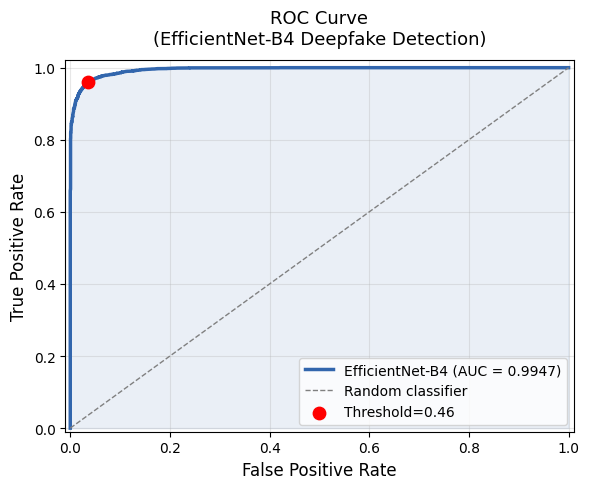

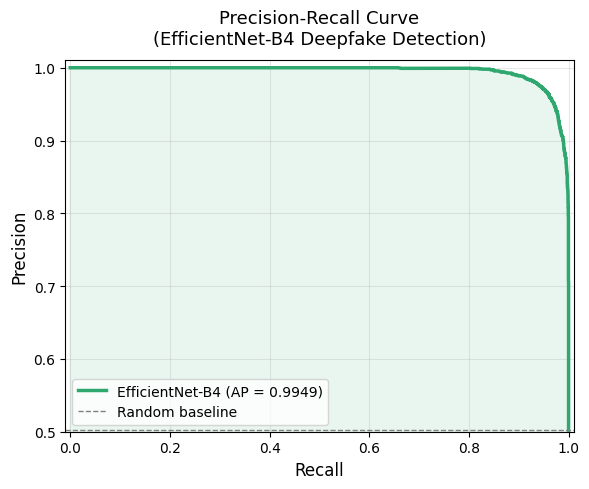

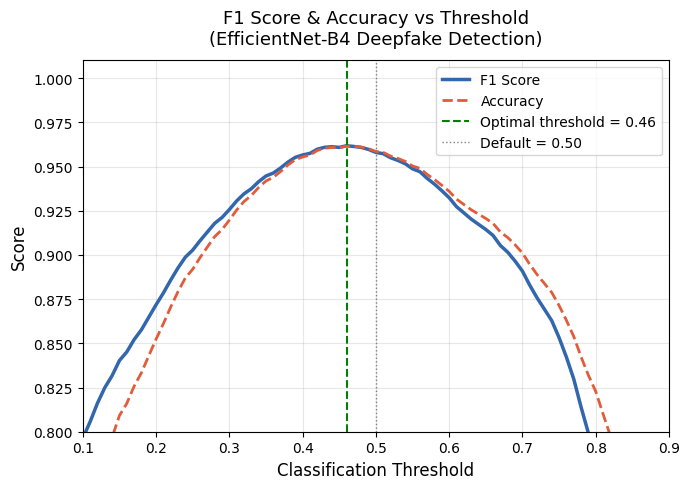

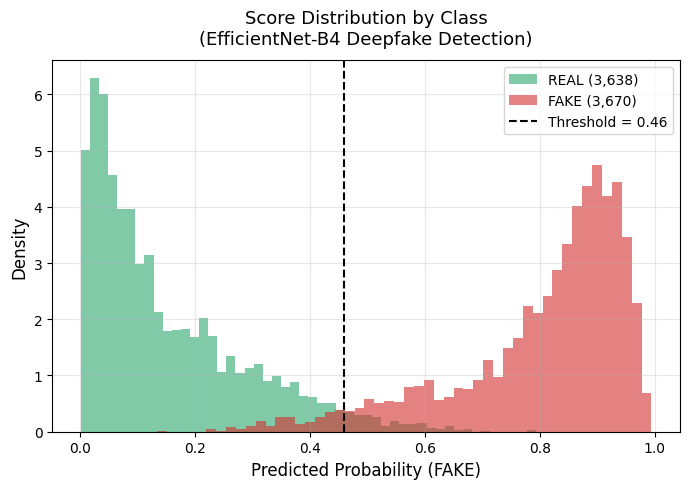


All charts saved to: D:/deepfake_project/logs


In [15]:
# CELL 6 — FULL TEST SET EVALUATION 
# Generates: Confusion Matrix, ROC Curve, PR Curve, F1 vs Threshold
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, accuracy_score
)
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from tqdm.notebook import tqdm
import seaborn as sns


class TestDataset(Dataset):
    def __init__(self, root_dir):
        self.samples = []
        for label_name, label_val in [('real', 0), ('fake', 1)]:
            folder = os.path.join(root_dir, 'test', label_name)
            if not os.path.exists(folder):
                print(f'  Missing: {folder}')
                continue
            for f in Path(folder).glob('*.npz'):
                self.samples.append((str(f), label_val))
        r = sum(1 for _, l in self.samples if l == 0)
        f = sum(1 for _, l in self.samples if l == 1)
        print(f'  Test set: {len(self.samples):,} images ({r:,} real / {f:,} fake)')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        fpath, label = self.samples[idx]
        img = np.load(fpath)['img']
        return torch.from_numpy(img.copy()).permute(2,0,1).float(), float(label)


print('Loading test dataset...')
test_ds     = TestDataset(PROCESSED_DIR)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False,
                          num_workers=0, pin_memory=True)

print('Running inference on test set...')
all_probs  = []
all_labels = []

model.eval()
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='Test', ncols=80):
        imgs = imgs.to(device, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=MODEL_CONFIG['use_amp'] and torch.cuda.is_available()):
            probs = torch.sigmoid(model(imgs)).cpu().numpy()
        all_probs.extend(probs.tolist())
        all_labels.extend(labels.int().numpy().tolist())
        del imgs

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)
y_pred     = (all_probs >= OPTIMAL_THRESHOLD).astype(int)

# Metrics
test_auc  = roc_auc_score(all_labels, all_probs)
test_acc  = accuracy_score(all_labels, y_pred)
test_f1   = f1_score(all_labels, y_pred)
ap_score  = average_precision_score(all_labels, all_probs)

print(f'\nTest Results (threshold={OPTIMAL_THRESHOLD:.2f})')
print(f'  AUC-ROC  : {test_auc:.4f}')
print(f'  Accuracy : {test_acc*100:.2f}%')
print(f'  F1 Score : {test_f1:.4f}')
print(f'  Avg Prec : {ap_score:.4f}')
print()
print(classification_report(all_labels, y_pred, target_names=['REAL', 'FAKE']))

# ── FIGURE 1: Confusion Matrix ────────────────────────────────────────────
cm = confusion_matrix(all_labels, y_pred)

fig1, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['REAL', 'FAKE'],
    yticklabels=['REAL', 'FAKE'],
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 16, 'weight': 'bold'},
    ax=ax
)
ax.set_title('Confusion Matrix\n(EfficientNet-B4 Deepfake Detection)', fontsize=13, pad=12)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
# Add percentages
total_real = cm[0].sum()
total_fake = cm[1].sum()
for i in range(2):
    for j in range(2):
        total = total_real if i == 0 else total_fake
        pct = cm[i,j] / total * 100
        ax.text(j+0.5, i+0.7, f'({pct:.1f}%)', ha='center', va='center',
                fontsize=9, color='gray')
plt.tight_layout()
fig1.savefig(os.path.join(LOG_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── FIGURE 2: ROC Curve ───────────────────────────────────────────────────
fpr, tpr, roc_thresh = roc_curve(all_labels, all_probs)

fig2, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#3266ad', linewidth=2.5,
        label=f'EfficientNet-B4 (AUC = {test_auc:.4f})')
ax.plot([0,1],[0,1], color='gray', linestyle='--', linewidth=1, label='Random classifier')
# Mark optimal threshold point
diffs = np.abs(roc_thresh - OPTIMAL_THRESHOLD)
opt_idx = np.argmin(diffs)
ax.scatter(fpr[opt_idx], tpr[opt_idx], color='red', zorder=5, s=80,
           label=f'Threshold={OPTIMAL_THRESHOLD:.2f}')
ax.fill_between(fpr, tpr, alpha=0.1, color='#3266ad')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve\n(EfficientNet-B4 Deepfake Detection)', fontsize=13, pad=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.02])
plt.tight_layout()
fig2.savefig(os.path.join(LOG_DIR, 'roc_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── FIGURE 3: Precision-Recall Curve ──────────────────────────────────────
precision, recall, pr_thresh = precision_recall_curve(all_labels, all_probs)

fig3, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall, precision, color='#2ea86e', linewidth=2.5,
        label=f'EfficientNet-B4 (AP = {ap_score:.4f})')
ax.axhline(y=all_labels.mean(), color='gray', linestyle='--', linewidth=1,
           label='Random baseline')
ax.fill_between(recall, precision, alpha=0.1, color='#2ea86e')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve\n(EfficientNet-B4 Deepfake Detection)', fontsize=13, pad=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([0.5, 1.01])
plt.tight_layout()
fig3.savefig(os.path.join(LOG_DIR, 'precision_recall_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── FIGURE 4: F1 Score vs Threshold ──────────────────────────────────────
thresholds_range = np.arange(0.1, 0.9, 0.01)
f1_list  = [f1_score(all_labels, (all_probs >= t).astype(int)) for t in thresholds_range]
acc_list = [accuracy_score(all_labels, (all_probs >= t).astype(int)) for t in thresholds_range]

fig4, ax = plt.subplots(figsize=(7, 5))
ax.plot(thresholds_range, f1_list,  color='#3266ad', linewidth=2.5, label='F1 Score')
ax.plot(thresholds_range, acc_list, color='#e05c3a', linewidth=2,   label='Accuracy', linestyle='--')
ax.axvline(x=OPTIMAL_THRESHOLD, color='green', linestyle='--', linewidth=1.5,
           label=f'Optimal threshold = {OPTIMAL_THRESHOLD:.2f}')
ax.axvline(x=0.5, color='gray', linestyle=':', linewidth=1, label='Default = 0.50')
ax.set_xlabel('Classification Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('F1 Score & Accuracy vs Threshold\n(EfficientNet-B4 Deepfake Detection)', fontsize=13, pad=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim([0.1, 0.9])
ax.set_ylim([0.8, 1.01])
plt.tight_layout()
fig4.savefig(os.path.join(LOG_DIR, 'f1_vs_threshold.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── FIGURE 5: Score Distribution ─────────────────────────────────────────
real_scores = all_probs[all_labels == 0]
fake_scores = all_probs[all_labels == 1]

fig5, ax = plt.subplots(figsize=(7, 5))
ax.hist(real_scores, bins=50, alpha=0.6, color='#2ea86e', label=f'REAL ({len(real_scores):,})', density=True)
ax.hist(fake_scores, bins=50, alpha=0.6, color='#d32f2f', label=f'FAKE ({len(fake_scores):,})', density=True)
ax.axvline(x=OPTIMAL_THRESHOLD, color='black', linestyle='--', linewidth=1.5,
           label=f'Threshold = {OPTIMAL_THRESHOLD:.2f}')
ax.set_xlabel('Predicted Probability (FAKE)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Score Distribution by Class\n(EfficientNet-B4 Deepfake Detection)', fontsize=13, pad=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
fig5.savefig(os.path.join(LOG_DIR, 'score_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\nAll charts saved to: {LOG_DIR}')

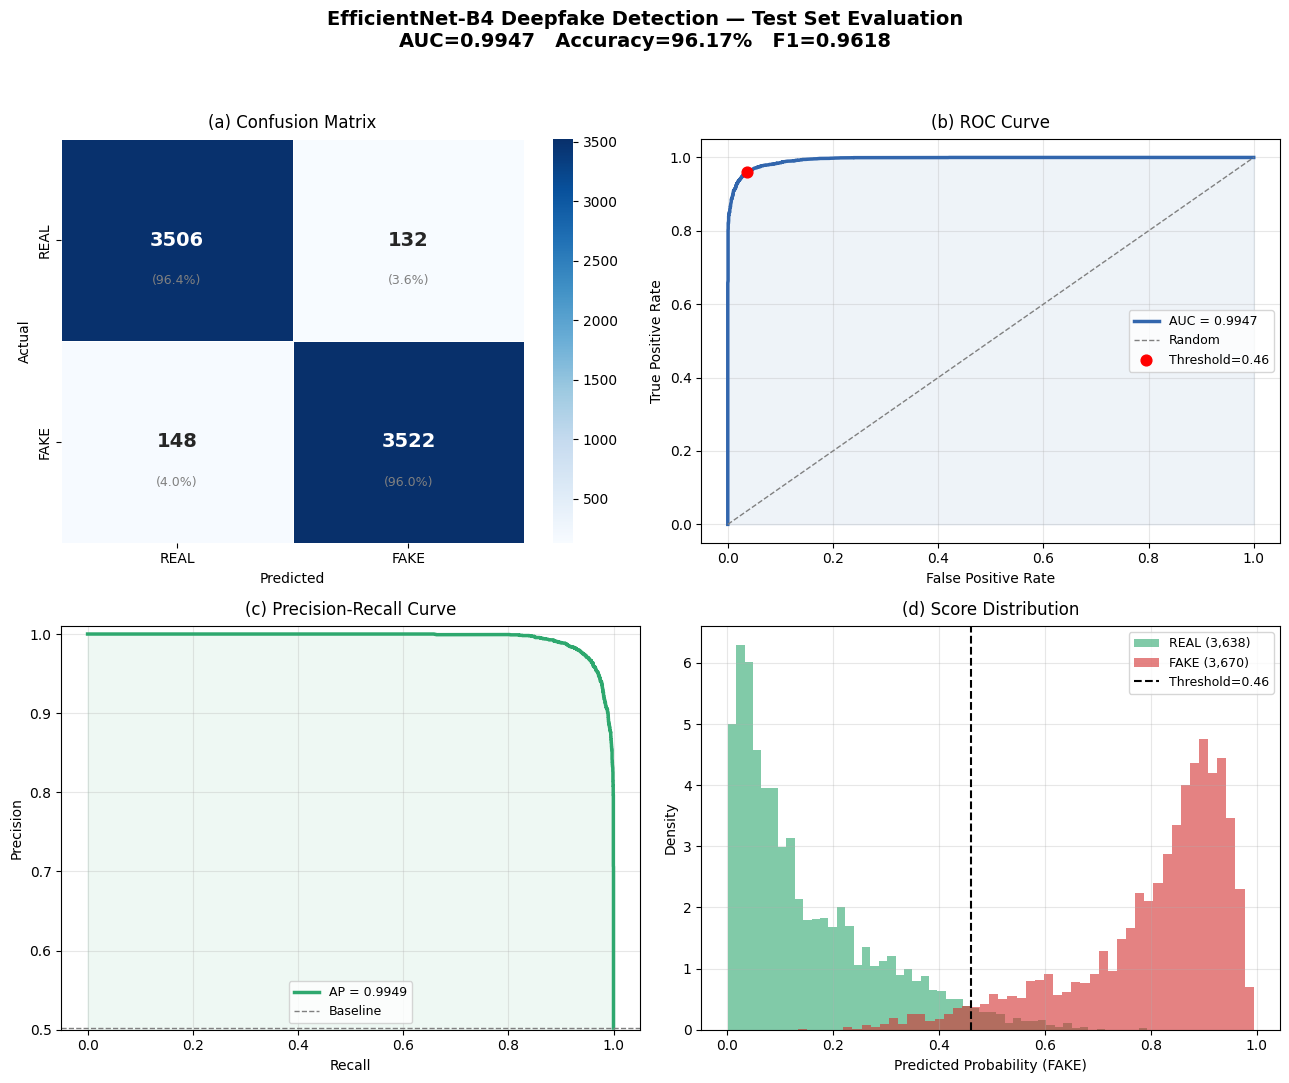

In [17]:
#  COMBINED RESEARCH PAPER FIGURE

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
fig.suptitle(
    f'EfficientNet-B4 Deepfake Detection — Test Set Evaluation\n'
    f'AUC={test_auc:.4f}   Accuracy={test_acc*100:.2f}%   F1={test_f1:.4f}',
    fontsize=14, fontweight='bold'
)

# 1. Confusion matrix
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'],
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 14, 'weight': 'bold'},
    ax=axes[0, 0]
)
for i in range(2):
    for j in range(2):
        total = cm[i].sum()
        pct   = cm[i,j] / total * 100
        axes[0,0].text(j+0.5, i+0.7, f'({pct:.1f}%)', ha='center',
                       va='center', fontsize=9, color='gray')
axes[0,0].set_title('(a) Confusion Matrix', fontsize=12, pad=8)
axes[0,0].set_xlabel('Predicted')
axes[0,0].set_ylabel('Actual')

# 2. ROC Curve
axes[0,1].plot(fpr, tpr, color='#3266ad', linewidth=2.5,
               label=f'AUC = {test_auc:.4f}')
axes[0,1].plot([0,1],[0,1], color='gray', linestyle='--', linewidth=1, label='Random')
axes[0,1].scatter(fpr[opt_idx], tpr[opt_idx], color='red', zorder=5, s=60,
                  label=f'Threshold={OPTIMAL_THRESHOLD:.2f}')
axes[0,1].fill_between(fpr, tpr, alpha=0.08, color='#3266ad')
axes[0,1].set_title('(b) ROC Curve', fontsize=12, pad=8)
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].legend(fontsize=9)
axes[0,1].grid(alpha=0.3)

# 3. Precision-Recall
axes[1,0].plot(recall, precision, color='#2ea86e', linewidth=2.5,
               label=f'AP = {ap_score:.4f}')
axes[1,0].axhline(y=all_labels.mean(), color='gray', linestyle='--', linewidth=1, label='Baseline')
axes[1,0].fill_between(recall, precision, alpha=0.08, color='#2ea86e')
axes[1,0].set_title('(c) Precision-Recall Curve', fontsize=12, pad=8)
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].legend(fontsize=9)
axes[1,0].grid(alpha=0.3)
axes[1,0].set_ylim([0.5, 1.01])

# 4. Score Distribution
axes[1,1].hist(real_scores, bins=50, alpha=0.6, color='#2ea86e',
               label=f'REAL ({len(real_scores):,})', density=True)
axes[1,1].hist(fake_scores, bins=50, alpha=0.6, color='#d32f2f',
               label=f'FAKE ({len(fake_scores):,})', density=True)
axes[1,1].axvline(x=OPTIMAL_THRESHOLD, color='black', linestyle='--', linewidth=1.5,
                  label=f'Threshold={OPTIMAL_THRESHOLD:.2f}')
axes[1,1].set_title('(d) Score Distribution', fontsize=12, pad=8)
axes[1,1].set_xlabel('Predicted Probability (FAKE)')
axes[1,1].set_ylabel('Density')
axes[1,1].legend(fontsize=9)
axes[1,1].grid(alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
out = os.path.join(LOG_DIR, 'research_paper_figure.png')
plt.savefig(out, dpi=200, bbox_inches='tight')
plt.show()


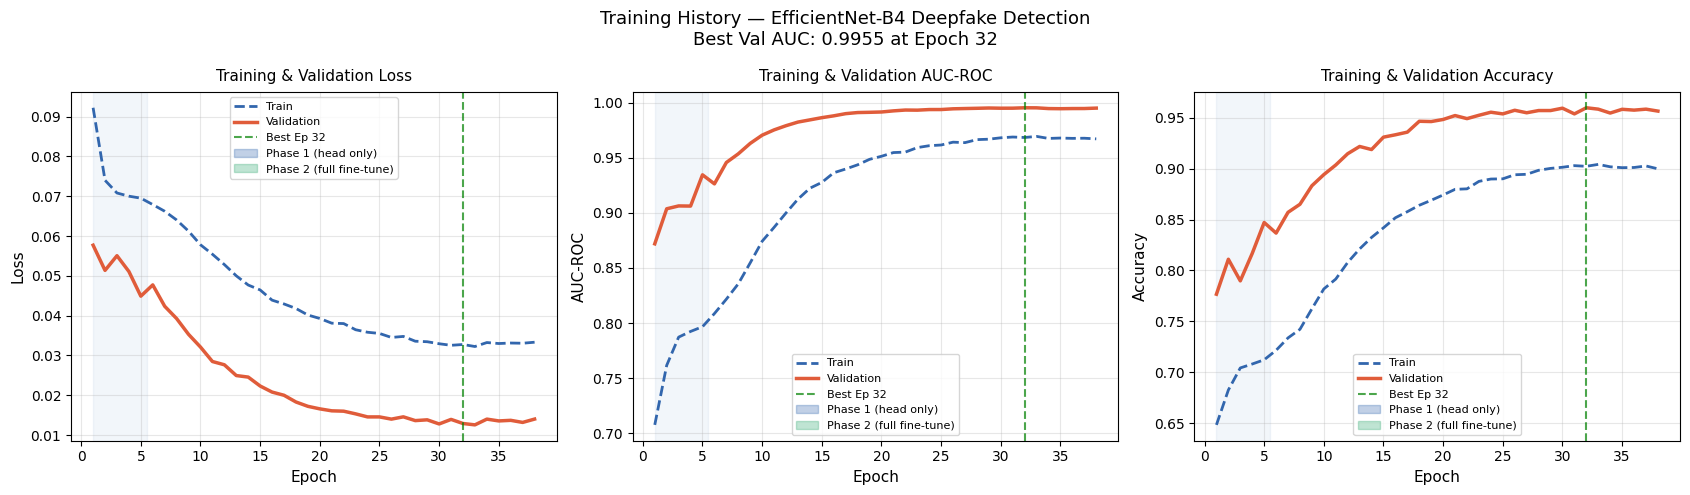

Training history chart saved: D:/deepfake_project/logs\training_history_final.png


In [18]:
# CELL 8 — TRAINING HISTORY CURVES (load from saved JSON)
import json

history_path = os.path.join(LOG_DIR, 'history_v3.json')
if not os.path.exists(history_path):
    print(f'history_v3.json not found at {history_path}')
    print('Trying history_v2.json...')
    history_path = os.path.join(LOG_DIR, 'history_v2.json')

if os.path.exists(history_path):
    with open(history_path) as f:
        history = json.load(f)

    epochs    = list(range(1, len(history['train_loss']) + 1))
    phases    = history.get('phase', [1]*len(epochs))
    p1_end    = max(i+1 for i, p in enumerate(phases) if p == 1)
    best_ep   = epochs[history['val_auc'].index(max(history['val_auc']))]

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    fig.suptitle(
        f'Training History — EfficientNet-B4 Deepfake Detection\n'
        f'Best Val AUC: {max(history["val_auc"]):.4f} at Epoch {best_ep}',
        fontsize=13
    )

    p1p = mpatches.Patch(color='#3266ad', alpha=0.3, label='Phase 1 (head only)')
    p2p = mpatches.Patch(color='#2ea86e', alpha=0.3, label='Phase 2 (full fine-tune)')

    for ax, m, title, ylabel in [
        (axes[0], 'loss', 'Training & Validation Loss',     'Loss'),
        (axes[1], 'auc',  'Training & Validation AUC-ROC',  'AUC-ROC'),
        (axes[2], 'acc',  'Training & Validation Accuracy', 'Accuracy'),
    ]:
        train_vals = history[f'train_{m}']
        val_vals   = history[f'val_{m}']

        # Handle NaN values from earlier broken runs
        val_clean = [v if v == v else None for v in val_vals]
        val_ep    = [e for e, v in zip(epochs, val_clean) if v is not None]
        val_v     = [v for v in val_clean if v is not None]

        ax.plot(epochs, train_vals, color='#3266ad', linewidth=2,
                label='Train', linestyle='--')
        ax.plot(val_ep, val_v, color='#e05c3a', linewidth=2.5, label='Validation')
        ax.axvspan(1, p1_end + 0.5, alpha=0.06, color='#3266ad')
        ax.axvline(x=best_ep, color='green', linestyle='--', alpha=0.7,
                   linewidth=1.5, label=f'Best Ep {best_ep}')
        ax.set_title(title, fontsize=11, pad=8)
        ax.set_xlabel('Epoch', fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.legend(handles=[ax.get_lines()[0], ax.get_lines()[1],
                            ax.get_lines()[2], p1p, p2p],
                  fontsize=8, loc='best')
        ax.grid(alpha=0.3)

    plt.tight_layout()
    out = os.path.join(LOG_DIR, 'training_history_final.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Training history chart saved: {out}')
else:
    print('No history JSON file found. Run the training notebook first.')